This routine generates **Figure 1** and its supplementary panels for the paper *"Global Potential of Potable Reuse Across Coupled Climate and Socioeconomic Futures"*. If you have any questions please contact [a.sarfraz@uu.nl](mailto:a.sarfraz@uu.nl).

## Figure 1

Panels (a) and (b) show ensemble boxplots of the global reduction in municipal and total freshwater withdrawal under PR50 and PR100 adoption. Panels (c) and (d) decompose the gross municipal saving under PR100 into a net withdrawal reduction and the share reallocated to each competing sector (irrigation, electricity, manufacturing, livestock, primary energy).

Supplementary panels stratify the (c)/(d) decomposition by each experimental factor (SSP, RCP, reuse cost, supply capacity), and an electricity-mechanism diagnostic links the irrigation and electricity reallocation back to the underlying generation mix.



### Imports

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")

### Setting directories

In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import yaml

# Resolve the repo root from this notebook's location.
_NB_DIR   = Path.cwd()
REPO_ROOT = _NB_DIR.parent if _NB_DIR.name == "notebooks" else _NB_DIR

sys.path.insert(0, str(REPO_ROOT / "src"))

# Load path config.
_cfg = yaml.safe_load((REPO_ROOT / "config" / "paths.yaml").read_text())

def _resolve(p):
    p = Path(p)
    return p if p.is_absolute() else (REPO_ROOT / p).resolve()

PATHS = {
    "data":    {k: _resolve(v) for k, v in _cfg["data"].items()},
    "outputs": {k: _resolve(v) for k, v in _cfg["outputs"].items()},
}

from potable_reuse.style import apply_style
from potable_reuse.io import load_scenario_query
from potable_reuse.plotting import save_all
apply_style()

CACHE_DIR = PATHS["data"]["cache_dir"]
FIG_DIR   = PATHS["outputs"]["figure1"]
FIG_DIR.mkdir(parents=True, exist_ok=True)

### Loading cached data



In [3]:
muni  = pd.read_parquet(CACHE_DIR / "combined_muni.parquet")
total = pd.read_parquet(CACHE_DIR / "combined_total.parquet")

print(f"muni  : {len(muni):,} rows | "
      f"{muni['scenario'].nunique()} scenarios")
print(f"total : {len(total):,} rows | "
      f"{total['scenario'].nunique()} scenarios")

muni  : 323,136 rows | 459 scenarios
total : 5,074,704 rows | 459 scenarios


### Constants and helpers


In [4]:
START_YEAR = 2025
END_YEAR   = 2100
DECADES    = [2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100]

PR_LEVELS = ["PR50", "PR100"]
PR_COLOR  = {"PR50": "#1565C0", "PR100": "#2E7D32"}

# Sector classification from'water mapping source'
SECTOR_MAP = {
    "water_td_muni_W":   "Municipal",
    "water_td_irr_W":    "Irrigation",
    "water_td_elec_W":   "Electricity",
    "water_td_ind_W":    "Manufacturing",
    "water_td_an_W":     "Livestock",
    "water_td_pri_W":    "Primary energy",
}
SECTOR_ORDER = [
    "Municipal", "Irrigation", "Electricity",
    "Manufacturing", "Livestock", "Primary energy",
]

# Fate categories on the (c)/(d) panels. Net retention plus the
# five reallocation channels.
FATE_ORDER = [
    "Net withdrawal reduction",
    "Reallocated to irrigation",
    "Reallocated to electricity",
    "Reallocated to manufacturing",
    "Reallocated to livestock",
    "Reallocated to primary energy",
]
FATE_COLOR = {
    "Net withdrawal reduction":      "#44BB99",  # mint
    "Reallocated to irrigation":     "#EE8866",  # light orange
    "Reallocated to electricity":    "#77AADD",  # light blue
    "Reallocated to manufacturing":  "#EEDD88",  # pale yellow
    "Reallocated to livestock":      "#BBCC33",  # pear
    "Reallocated to primary energy": "#FFAABB",  # light pink
}
FATE_COL = {f: f.lower().replace(" ", "_") for f in FATE_ORDER}


def hex_to_rgba_mpl(hex_color, alpha):
    """Convert a hex color to an RGBA tuple matplotlib accepts."""
    h = hex_color.lstrip("#")
    r = int(h[0:2], 16) / 255
    g = int(h[2:4], 16) / 255
    b = int(h[4:6], 16) / 255
    return (r, g, b, alpha)


def hex_to_rgba(hex_color, alpha):
    """Convert a hex color to a Plotly rgba(...) string."""
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

### Aggregating to global totals

Both the boxplots and the fate decomposition need scenario-by-scenario global sums. 

In [5]:
def sum_to_global(df, value_col="value"):
    """Collapse a scenario-region-year frame to global totals."""
    df = df[(df["year"] >= START_YEAR) & (df["year"] <= END_YEAR)]
    keys = ["scenario", "ssp_rcp", "ssp", "rcp",
            "rc", "supply", "pr", "year"]
    keys = [k for k in keys if k in df.columns]
    return (df.groupby(keys)[value_col]
              .sum()
              .reset_index()
              .rename(columns={value_col: "withdrawal"}))


def compute_pct_reduction(df, id_cols):
    """Pair each PR scenario with its matched PR0 baseline
    and compute the percentage reduction on `withdrawal`."""
    ref = (df[df["pr"] == "PR0"][id_cols + ["withdrawal"]]
             .rename(columns={"withdrawal": "ref"}))
    out = df[df["pr"] != "PR0"].merge(ref, on=id_cols, how="left")
    out["pct_reduction"] = (out["ref"] - out["withdrawal"]) / out["ref"] * 100
    return out


# Global totals: total freshwater (top-level sum of `total`)
# and municipal-only.
total_glob = sum_to_global(total)
muni_glob  = sum_to_global(muni)

# Reductions vs the matched PR0 baseline.
id_cols = ["ssp_rcp", "rc", "supply", "year"]
total_red = compute_pct_reduction(total_glob, id_cols)
muni_red  = compute_pct_reduction(muni_glob,  id_cols)

print(f"total_red : {len(total_red):,} rows")
print(f"muni_red  : {len(muni_red):,} rows")

total_red : 4,896 rows
muni_red  : 4,896 rows


### Figure 1a, 1b: global withdrawal boxplots

Decadal boxes pair PR50 (blue) and PR100 (green) at each year. PNG, SVG, and HTML outputs land in `outputs/figure1/`.

  Saved: fig1ab_decadal_boxplots.png | fig1ab_decadal_boxplots.svg | fig1ab_decadal_boxplots.html


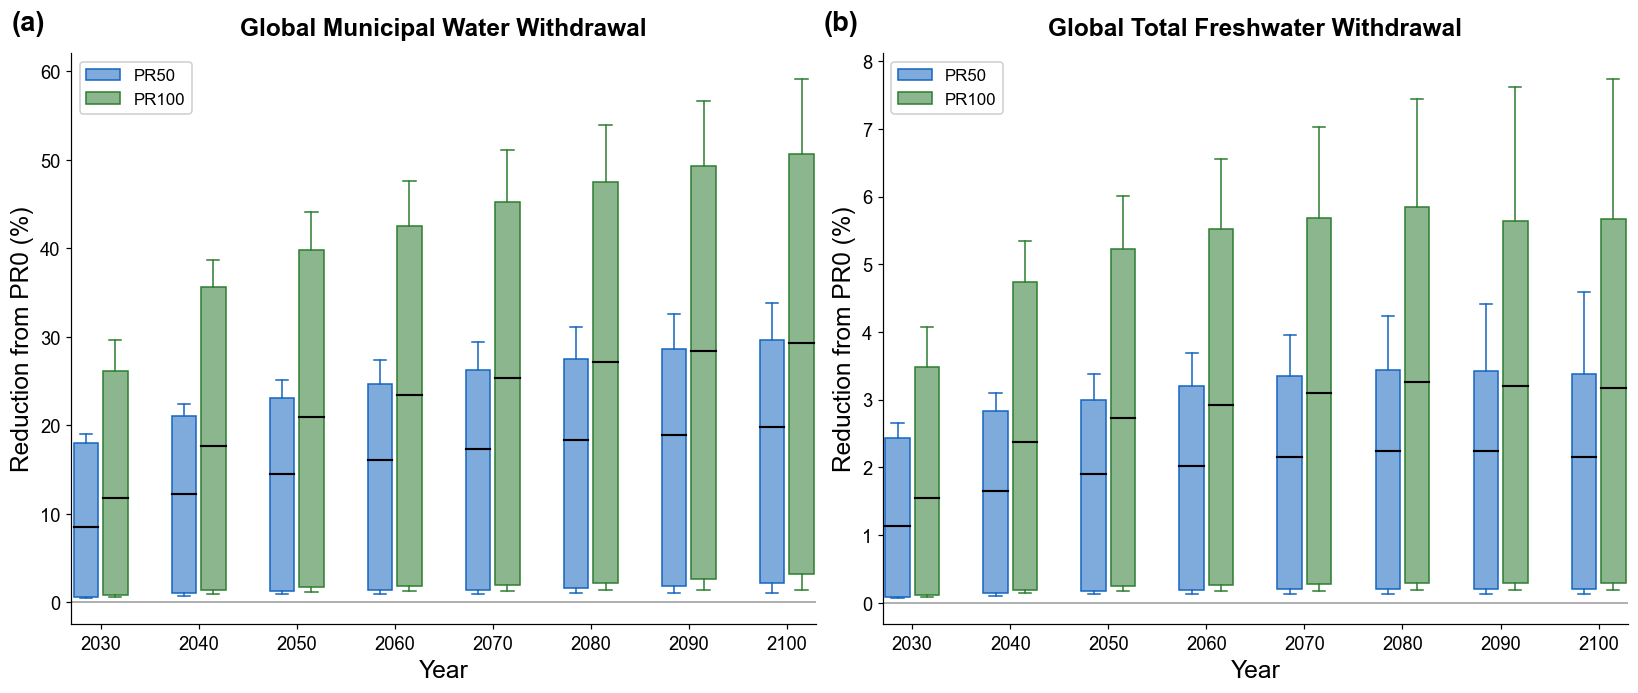

  Saved: figSI_5yr_boxplots.png | figSI_5yr_boxplots.svg | figSI_5yr_boxplots.html


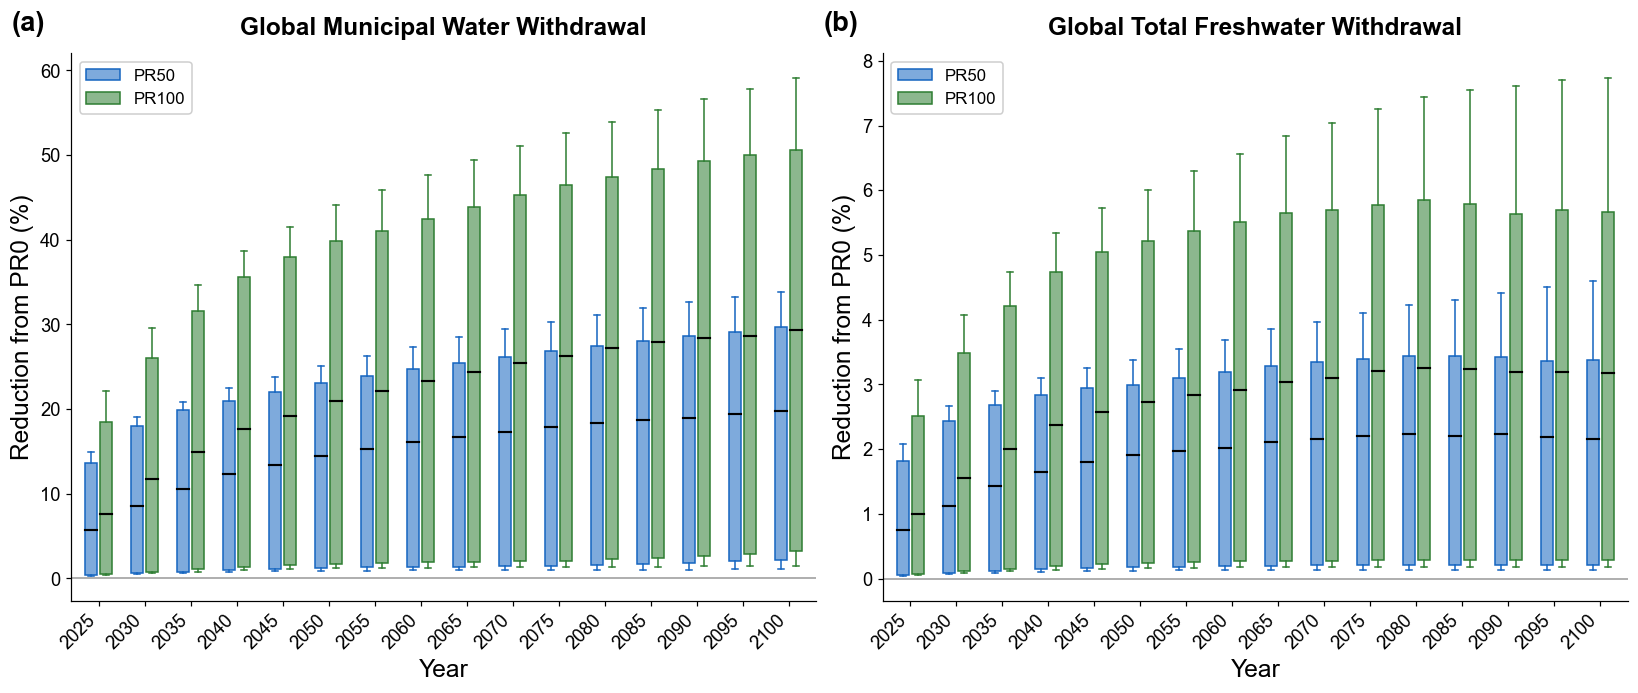

In [6]:
def boxplot_two_panels(total_red, muni_red, years,
                       out_stem,
                       box_width=2.5, offset=3.0,
                       x_tick_rotation=0):
    """Two-panel ensemble boxplot: total (left), municipal (right)."""
    panels = [
        ("a", "Global Municipal Water Withdrawal",  muni_red),
        ("b", "Global Total Freshwater Withdrawal", total_red),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6.4))

    for ax, (letter, title, df) in zip(axes, panels):
        for pi, pr in enumerate(PR_LEVELS):
            pos = [y + (pi - 0.5) * offset for y in years]
            data = [df[(df["pr"] == pr) & (df["year"] == y)]
                      ["pct_reduction"].dropna().values
                    for y in years]
            ax.boxplot(
                data, positions=pos, widths=box_width,
                patch_artist=True, showfliers=False,
                medianprops=dict(color="black", linewidth=1.4),
                whiskerprops=dict(color=PR_COLOR[pr], linewidth=1.0),
                capprops=dict(color=PR_COLOR[pr], linewidth=1.0),
                boxprops=dict(
                    facecolor=hex_to_rgba_mpl(PR_COLOR[pr], 0.55),
                    edgecolor=PR_COLOR[pr], linewidth=1.0),
                zorder=3,
            )

        ax.axhline(0, color="#555", linewidth=1.0, alpha=0.6, zorder=1)
        ax.set_title(title, fontweight="bold", pad=12)
        ax.set_xlabel("Year")
        ax.set_ylabel("Reduction from PR0 (%)")
        ax.set_xticks(years)
        ax.set_xticklabels(
            [str(y) for y in years],
            rotation=x_tick_rotation,
            ha="right" if x_tick_rotation else "center")

        span = years[-1] - years[0]
        pad  = max(3, span * 0.04)
        ax.set_xlim(years[0] - pad, years[-1] + pad)

        handles = [
            mpatches.Patch(
                facecolor=hex_to_rgba_mpl(PR_COLOR[pr], 0.55),
                edgecolor=PR_COLOR[pr], label=pr)
            for pr in PR_LEVELS
        ]
        ax.legend(handles=handles, loc="upper left", framealpha=0.95)

        ax.text(-0.08, 1.03, f"({letter})",
                transform=ax.transAxes,
                fontsize=18, fontweight="bold",
                va="bottom", ha="left")

    fig.tight_layout()
    save_all(fig, FIG_DIR, out_stem)
    plt.show()
    plt.close(fig)


# Decadal version (8 points)
boxplot_two_panels(total_red, muni_red, DECADES,
                   out_stem="fig1ab_decadal_boxplots",
                   box_width=2.5, offset=3.0)

# Five-yearly version (16 points): SI variant.
all_years = sorted(int(y) for y in total_red["year"].unique()
                   if START_YEAR <= int(y) <= END_YEAR)
boxplot_two_panels(total_red, muni_red, all_years,
                   out_stem="figSI_5yr_boxplots",
                   box_width=1.3, offset=1.6,
                   x_tick_rotation=45)

In [7]:
# =============================================================================
# Headline percentages for Figure 1, panels (a) and (b) to add to paper
#   Reproduces the box statistics from boxplot_two_panels() exactly:
#   median = q50, box = q25-q75, whiskers = q05-q95 (showfliers=False).
# =============================================================================
import numpy as np
import pandas as pd

PR_REPORT = ["PR50", "PR100"]
YEARS     = DECADES                          # 2030, 2040, ..., 2100
QS        = [0.05, 0.25, 0.50, 0.75, 0.95]


def pct_quantile_table(df, label):
    """Long table of q05/q25/q50/q75/q95 of pct_reduction per (pr, year)."""
    rows = []
    for pr in PR_REPORT:
        for y in YEARS:
            vals = (df[(df["pr"] == pr) & (df["year"] == y)]
                    ["pct_reduction"].dropna().values)
            if vals.size == 0:
                continue
            q = np.quantile(vals, QS)
            rows.append({
                "panel": label, "pr": pr, "year": int(y), "n": int(vals.size),
                "q05": q[0], "q25": q[1], "q50": q[2], "q75": q[3], "q95": q[4],
            })
    return pd.DataFrame(rows).round(2)


def pct_text(tbl, label, title):
    lines = [f"\n{'=' * 76}",
             f"  Panel {label}  —  {title}  (% reduction from PR0)",
             f"{'=' * 76}"]
    for pr in PR_REPORT:
        lines.append(f"\n  {pr}")
        lines.append(f"    {'year':<6}{'median':>10}{'IQR (q25-q75)':>22}"
                     f"{'5-95% (q05-q95)':>24}{'  n':>6}")
        for _, r in tbl[tbl["pr"] == pr].iterrows():
            iqr  = f"{r['q25']:.2f}-{r['q75']:.2f}"
            wide = f"{r['q05']:.2f}-{r['q95']:.2f}"
            lines.append(f"    {int(r['year']):<6}{r['q50']:>10.2f}"
                         f"{iqr:>22}{wide:>24}{int(r['n']):>6}")
    return "\n".join(lines)


# Panel (a): municipal
panel_a = pct_quantile_table(muni_red,  label="(a) municipal %")
# Panel (b): total freshwater
panel_b = pct_quantile_table(total_red, label="(b) TFW %")

panel_a.to_csv(FIG_DIR / "panel_a_municipal_pct_reduction.csv", index=False)
panel_b.to_csv(FIG_DIR / "panel_b_tfw_pct_reduction.csv",       index=False)

text = (pct_text(panel_a, "(a)", "Global Municipal Water Withdrawal") + "\n"
      + pct_text(panel_b, "(b)", "Global Total Freshwater Withdrawal"))

(FIG_DIR / "headline_pct_reductions.txt").write_text(text, encoding="utf-8")
print(text)
print(f"\nWrote {FIG_DIR / 'headline_pct_reductions.txt'}")
print(f"Wrote {FIG_DIR / 'panel_a_municipal_pct_reduction.csv'}")
print(f"Wrote {FIG_DIR / 'panel_b_tfw_pct_reduction.csv'}")


  Panel (a)  —  Global Municipal Water Withdrawal  (% reduction from PR0)

  PR50
    year      median         IQR (q25-q75)         5-95% (q05-q95)     n
    2030        8.50            0.62-18.02              0.49-19.01   153
    2040       12.28            1.02-21.01              0.76-22.01   153
    2050       14.50            1.27-23.04              0.92-24.31   153
    2060       16.06            1.36-24.71              1.00-26.12   153
    2070       17.35            1.44-26.20              1.09-27.89   153
    2080       18.39            1.58-27.46              1.18-29.52   153
    2090       18.89            1.83-28.61              1.23-30.82   153
    2100       19.80            2.20-29.65              1.25-32.54   153

  PR100
    year      median         IQR (q25-q75)         5-95% (q05-q95)     n
    2030       11.77            0.80-26.09              0.61-29.40   153
    2040       17.65            1.38-35.57              1.01-37.84   153
    2050       20.98            

### Figure 1c, 1d: cross-sectoral fate decomposition

Under PR100 the gross municipal saving is partitioned into a net municipal reduction and reallocations to the five competing sectors. Panel (c) reports the absolute volumes in km^3 yr^-1; panel (d) the same as percentage shares of the gross saving.

In [8]:
def classify_input(inp):
    """Map a GCAM `input` field to one of our six sectors.
    """
    if not isinstance(inp, str):
        return "Other"
    s = inp.lower()
    if s.startswith("water_td_irr"): return "Irrigation"
    if s == "water_td_muni_w":       return "Municipal"
    if s == "water_td_an_w":         return "Livestock"
    if s == "water_td_elec_w":       return "Electricity"
    if s == "water_td_ind_w":        return "Manufacturing"
    if s == "water_td_pri_w":        return "Primary energy"
    return "Other"


def build_sectoral_long(total, muni):
    """Stack non-municipal sectors (from `total`) onto the
    municipal cache (`muni`).

    """
    t = total.copy()
    t["sector"] = t["input"].map(classify_input)
    t = t[~t["sector"].isin(["Municipal", "Other"])]

    m = muni.copy()
    m["sector"] = "Municipal"

    # Derive ssp / rcp from ssp_rcp on either frame if not already present.
    for f in (t, m):
        if "ssp" not in f.columns and "ssp_rcp" in f.columns:
            f["ssp"] = f["ssp_rcp"].str.split("_").str[0]
        if "rcp" not in f.columns and "ssp_rcp" in f.columns:
            f["rcp"] = f["ssp_rcp"].str.split("_").str[1]

    keep = ["scenario", "ssp_rcp", "ssp", "rcp",
            "rc", "supply", "pr", "region", "year", "sector", "value"]
    keep_t = [c for c in keep if c in t.columns]
    keep_m = [c for c in keep if c in m.columns]
    return pd.concat([t[keep_t], m[keep_m]], ignore_index=True)


def aggregate_global_by_sector(df):
    """Sum withdrawals to (sector, year, scenario design) global totals."""
    df = df[(df["year"] >= START_YEAR) & (df["year"] <= END_YEAR)]
    df = df[df["sector"].isin(SECTOR_ORDER)]
    keys = ["ssp_rcp", "ssp", "rcp", "rc", "supply",
            "pr", "sector", "year"]
    return df.groupby(keys, as_index=False)["value"].sum()


def compute_sectoral_delta(global_by_sector):
    """Per-sector delta against the matched PR0 baseline."""
    id_cols = ["ssp_rcp", "ssp", "rcp", "rc", "supply",
               "sector", "year"]
    ref = (global_by_sector[global_by_sector["pr"] == "PR0"]
             [id_cols + ["value"]]
             .rename(columns={"value": "ref"}))
    out = global_by_sector[global_by_sector["pr"] != "PR0"].merge(
        ref, on=id_cols, how="left")
    out["delta"] = out["value"] - out["ref"]
    return out


def fate_table(global_delta):
    """Decompose ensemble-median deltas into the six fate channels.

    For a given (pr, year):
        gross_municipal     = -median(delta for Municipal)        (>= 0)
        reallocation[s]     = max(0, median(delta for sector s))  for s != Municipal
        net_reduction       = max(0, gross_municipal - sum reallocations)
    """
    med = (global_delta
           .groupby(["pr", "sector", "year"], as_index=False)["delta"]
           .median())
    rows = []
    for (pr, year), sub in med.groupby(["pr", "year"]):
        s = dict(zip(sub["sector"], sub["delta"]))
        muni = -s.get("Municipal", 0.0)
        if muni <= 0:
            continue
        row = {"pr": pr, "year": year, "gross_municipal": muni}
        net = muni
        for sector in ["Irrigation", "Electricity",
                       "Manufacturing", "Livestock",
                       "Primary energy"]:
            realloc = max(0.0, s.get(sector, 0.0))
            row[FATE_COL[f"Reallocated to {sector.lower()}"]] = realloc
            net -= realloc
        row[FATE_COL["Net withdrawal reduction"]] = max(0.0, net)
        rows.append(row)
    return pd.DataFrame(rows)


def gross_percentiles(global_delta):
    """Whiskers for the gross-reduction marker on panel (c)."""
    muni = (global_delta[global_delta["sector"] == "Municipal"]
            .copy())
    muni["gross"] = -muni["delta"]
    return (muni.groupby(["pr", "year"], as_index=False)
                .agg(median=("gross", "median"),
                     q25=("gross", lambda s: s.quantile(0.25)),
                     q75=("gross", lambda s: s.quantile(0.75)),
                     q05=("gross", lambda s: s.quantile(0.05)),
                     q95=("gross", lambda s: s.quantile(0.95))))


sectoral_long    = build_sectoral_long(total, muni)
global_by_sector = aggregate_global_by_sector(sectoral_long)
global_delta     = compute_sectoral_delta(global_by_sector)
fate             = fate_table(global_delta)
gross            = gross_percentiles(global_delta)

# re-check
print("Sectors present in global_delta:")
print(global_delta
      .groupby("sector")["delta"]
      .apply(lambda s: f"n={len(s):,d}, median delta={s.median():+.2f}")
      .to_string())

print(f"\nfate    : {len(fate):,} rows ({fate['pr'].unique()})")
print(f"gross   : {len(gross):,} rows")

Sectors present in global_delta:
sector
Electricity         n=4,896, median delta=+3.01
Irrigation          n=4,896, median delta=+9.09
Livestock           n=4,896, median delta=+0.02
Manufacturing       n=4,896, median delta=+0.10
Municipal         n=4,896, median delta=-113.13
Primary energy      n=4,896, median delta=-0.01

fate    : 32 rows (['PR100' 'PR50'])
gross   : 32 rows


  Saved: fig1cd_PR100_fate_decomposition.png | fig1cd_PR100_fate_decomposition.svg | fig1cd_PR100_fate_decomposition.html


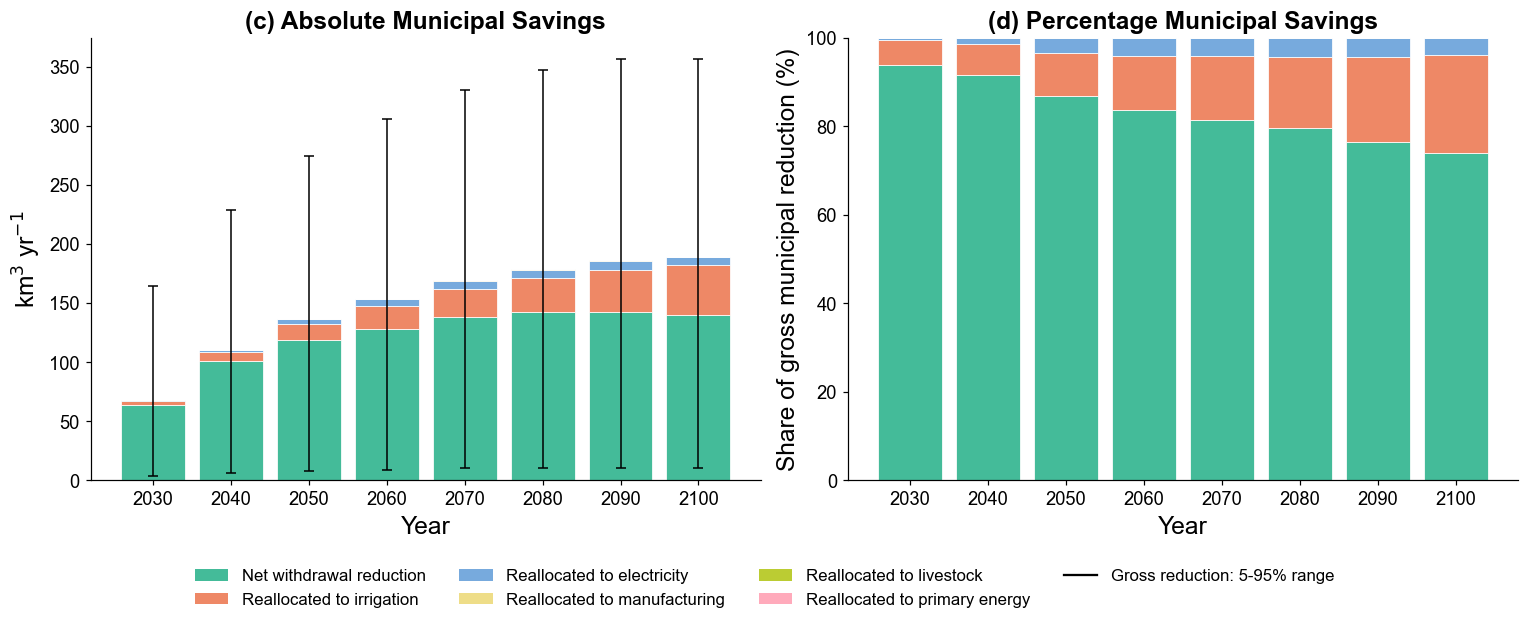

  Saved: figSI_PR50_fate_decomposition.png | figSI_PR50_fate_decomposition.svg | figSI_PR50_fate_decomposition.html


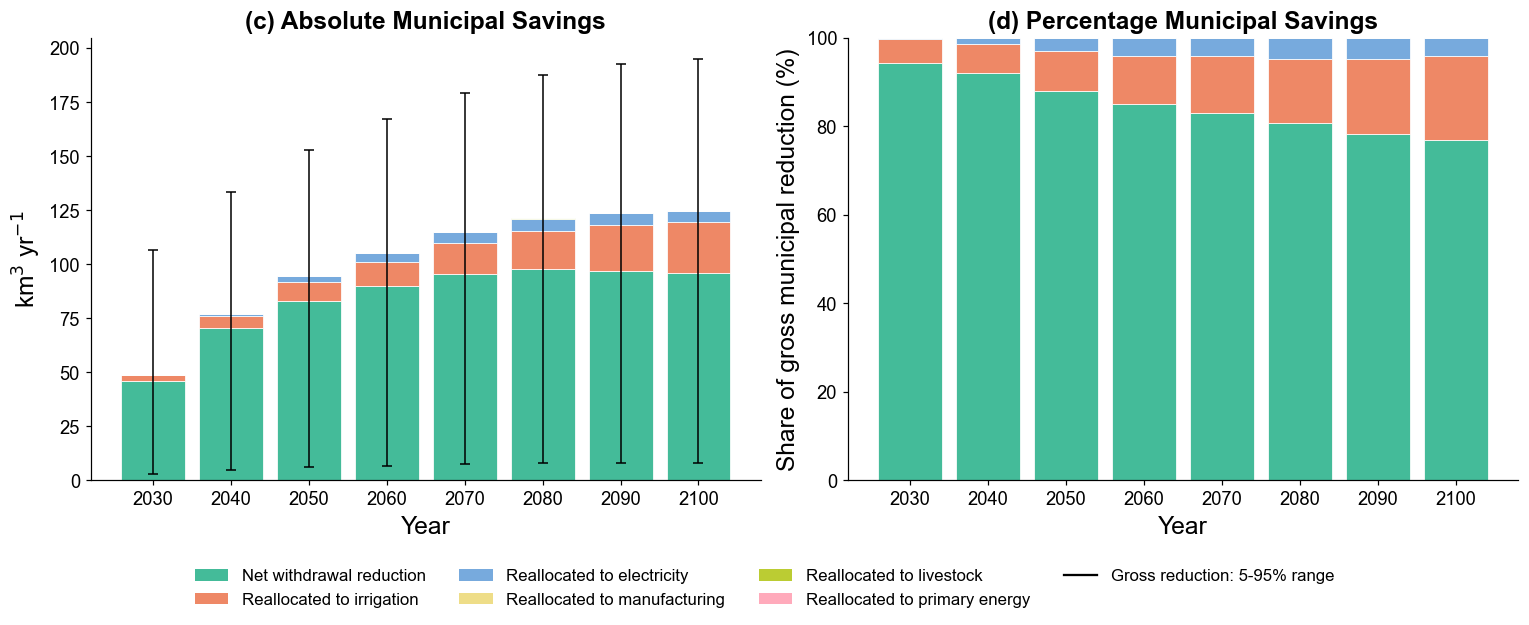

In [9]:
def fate_two_panels(fate_df, gross_df, pr, out_stem):
    """Two-panel decomposition: absolute (left), proportional (right)."""
    f_pr = fate_df[fate_df["pr"] == pr].set_index("year").reindex(DECADES)
    g_pr = gross_df[gross_df["pr"] == pr].set_index("year").reindex(DECADES)
    x    = np.arange(len(DECADES))

    fig, (ax_abs, ax_prop) = plt.subplots(1, 2, figsize=(14, 5.6),
                                         sharex=False, sharey=False)

    # Left: stacked absolute volumes plus a 5-95% whisker on the
    # gross-saving marker.
    bottom = np.zeros(len(DECADES))
    for fate_name in FATE_ORDER:
        col  = FATE_COL[fate_name]
        vals = f_pr[col].fillna(0).to_numpy()
        ax_abs.bar(x, vals, bottom=bottom, width=0.82,
                   color=FATE_COLOR[fate_name],
                   edgecolor="white", linewidth=0.5,
                   label=fate_name)
        bottom += vals

    g_med = g_pr["median"].to_numpy()
    err_lo = np.clip(g_med - g_pr["q05"].to_numpy(), 0, None)
    err_hi = np.clip(g_pr["q95"].to_numpy() - g_med, 0, None)
    ax_abs.errorbar(x, g_med, yerr=[err_lo, err_hi],
                    fmt="none", ecolor="#000",
                    elinewidth=1.0, capsize=3.0, capthick=1.0, zorder=10)

    ax_abs.set_xticks(x)
    ax_abs.set_xticklabels(DECADES, rotation=0)
    ax_abs.set_xlabel("Year")
    ax_abs.set_ylabel("km$^3$ yr$^{-1}$")
    ax_abs.set_title(f"(c) Absolute Municipal Savings", fontweight="bold")

    # Right: stacked proportional shares.
    total_per_yr = f_pr[[FATE_COL[f] for f in FATE_ORDER]].sum(axis=1)
    bottom = np.zeros(len(DECADES))
    for fate_name in FATE_ORDER:
        col  = FATE_COL[fate_name]
        vals = (f_pr[col].fillna(0) / total_per_yr.replace(0, np.nan)
                * 100).fillna(0).to_numpy()
        ax_prop.bar(x, vals, bottom=bottom, width=0.82,
                    color=FATE_COLOR[fate_name],
                    edgecolor="white", linewidth=0.5,
                    label=fate_name)
        bottom += vals

    ax_prop.set_xticks(x)
    ax_prop.set_xticklabels(DECADES, rotation=0)
    ax_prop.set_xlabel("Year")
    ax_prop.set_ylabel("Share of gross municipal reduction (%)")
    ax_prop.set_ylim(0, 100)
    ax_prop.set_title(f"(d) Percentage Municipal Savings", fontweight="bold")

    handles = [Patch(facecolor=FATE_COLOR[f], label=f) for f in FATE_ORDER]
    handles.append(plt.Line2D([0], [0], color="#000", linewidth=1.5,
                              label="Gross reduction: 5-95% range"))
    fig.legend(handles=handles, loc="lower center", ncol=4,
               frameon=False, bbox_to_anchor=(0.5, -0.05))
    fig.tight_layout(rect=[0, 0.06, 1, 0.97])
    save_all(fig, FIG_DIR, out_stem)
    plt.show()
    plt.close(fig)


# Figure 1c, 1d: PR100 only
fate_two_panels(fate, gross, pr="PR100",
                out_stem="fig1cd_PR100_fate_decomposition")

# SI counterpart at PR50.
fate_two_panels(fate, gross, pr="PR50",
                out_stem="figSI_PR50_fate_decomposition")

### Supplementary: stratified by scenario parameter

Re-runs the (c)/(d) decomposition once per stratum of each scenario factor,to verify that the cross-sectoral fate composition is robust across SSP, RCP, reuse cost, and supply-capacity assumptions.

  Saved: figSI_fate_stratified_by_ssp.png | figSI_fate_stratified_by_ssp.svg | figSI_fate_stratified_by_ssp.html


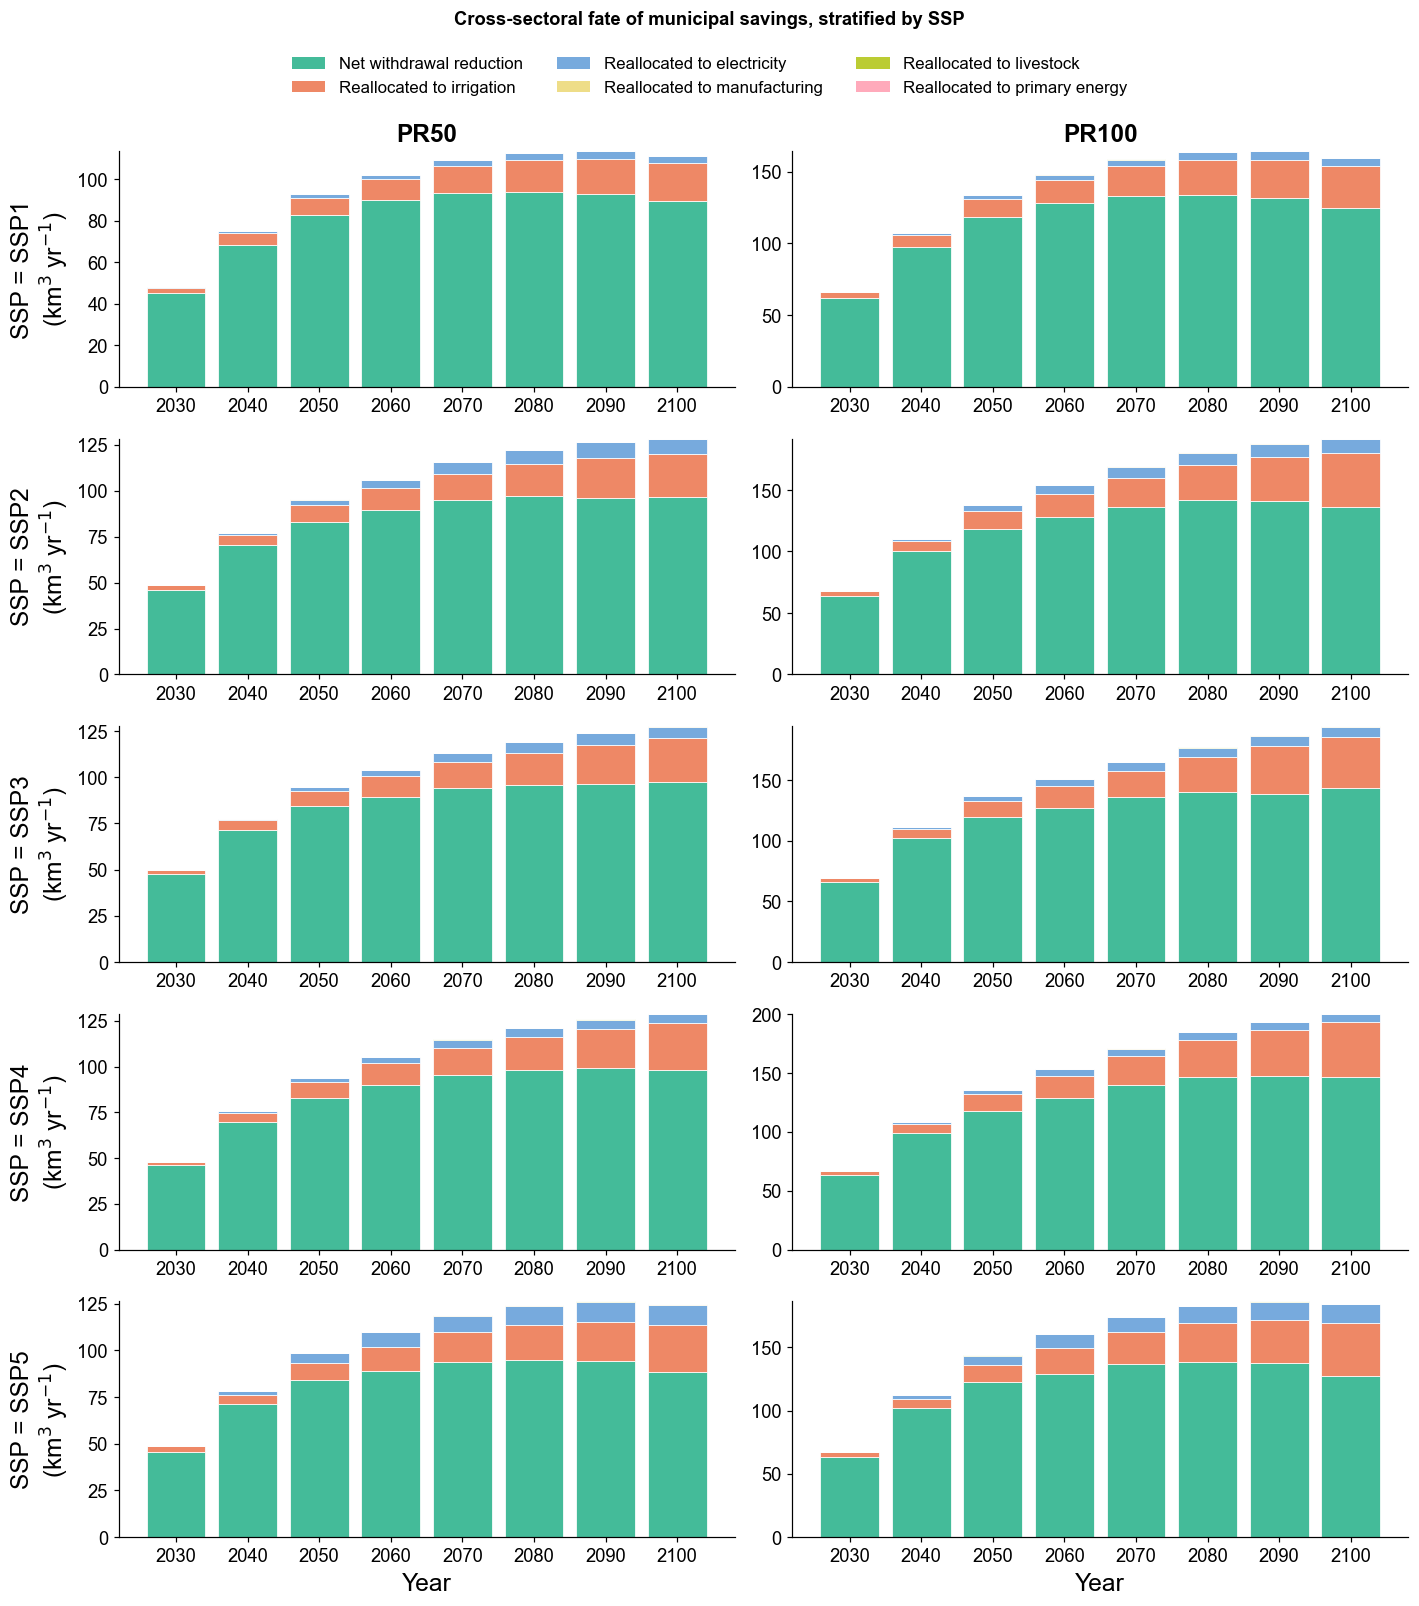

  Saved: figSI_fate_stratified_by_rcp.png | figSI_fate_stratified_by_rcp.svg | figSI_fate_stratified_by_rcp.html


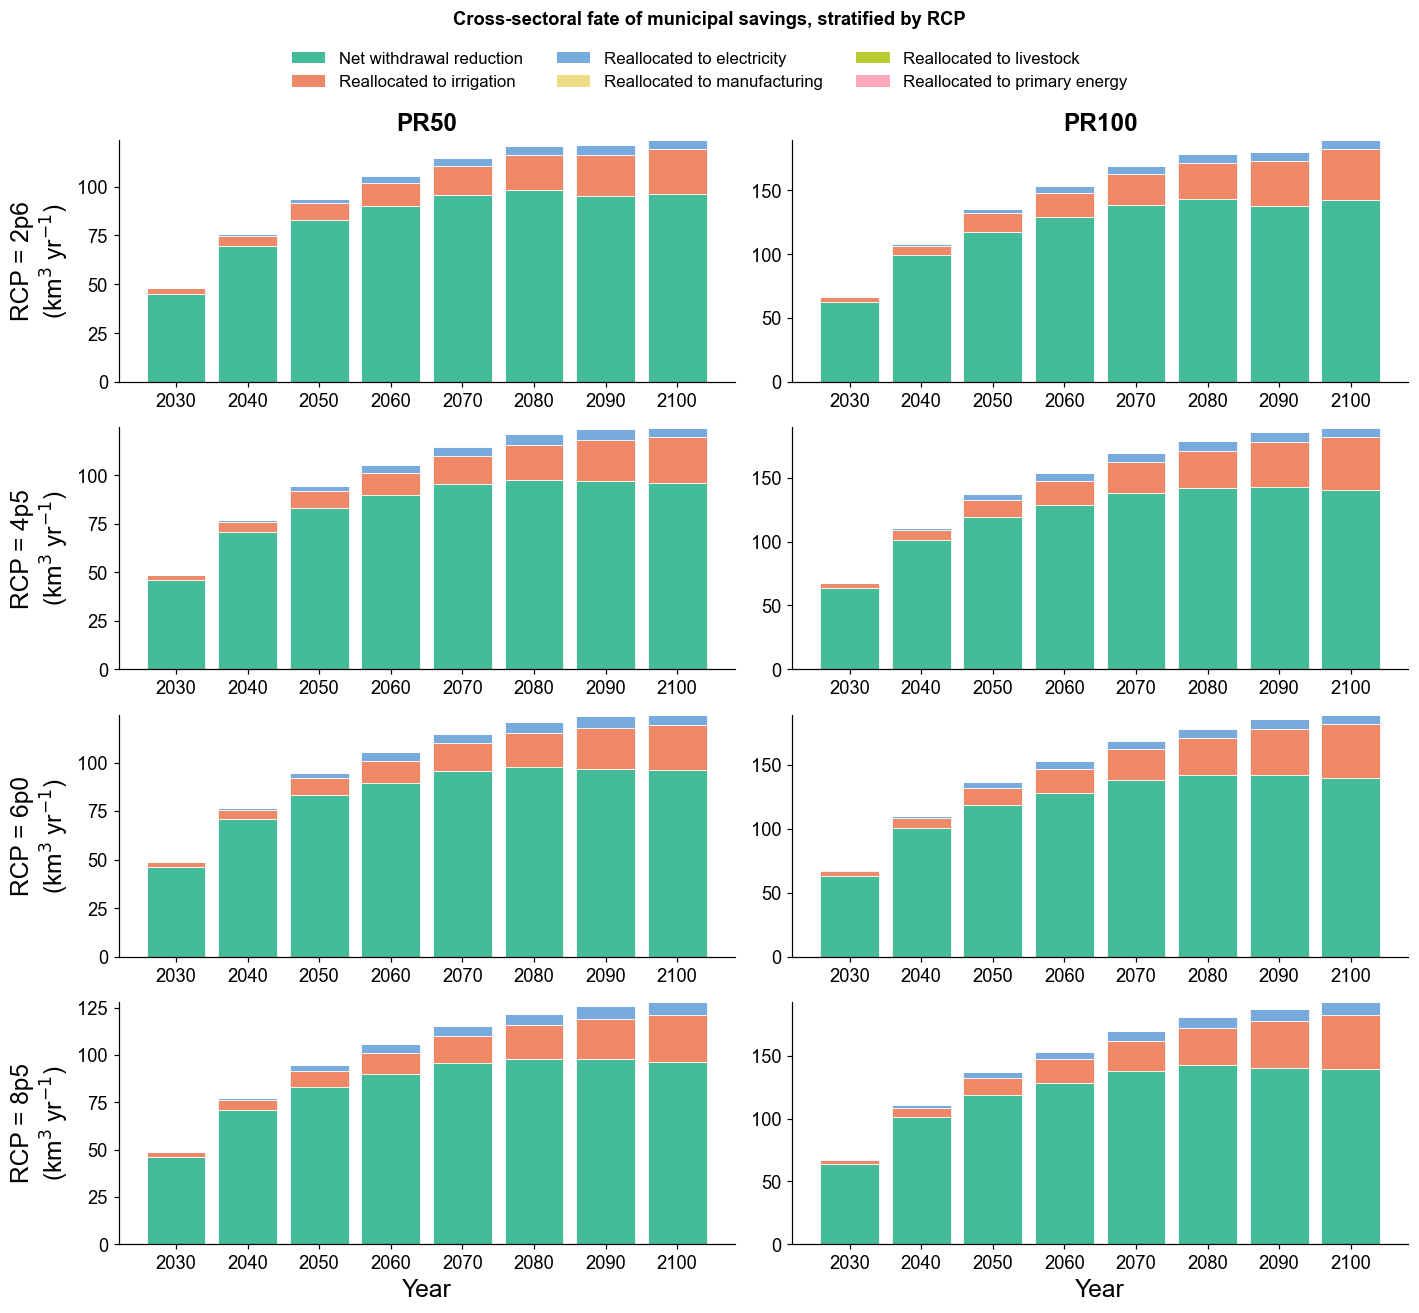

  Saved: figSI_fate_stratified_by_reuse_cost.png | figSI_fate_stratified_by_reuse_cost.svg | figSI_fate_stratified_by_reuse_cost.html


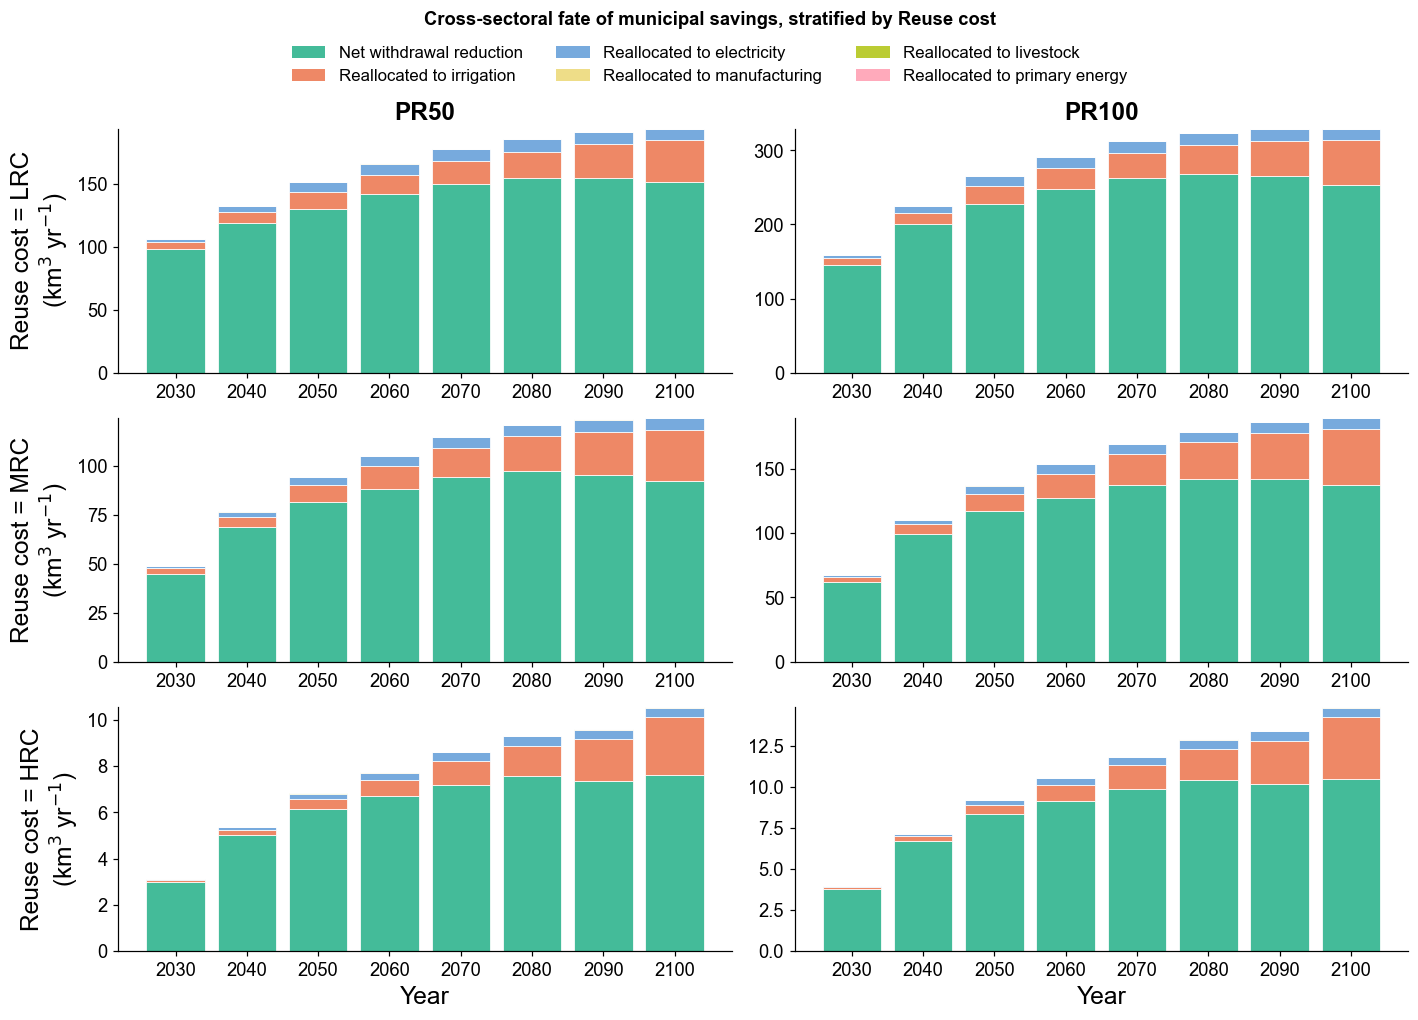

  Saved: figSI_fate_stratified_by_supply_capacity.png | figSI_fate_stratified_by_supply_capacity.svg | figSI_fate_stratified_by_supply_capacity.html


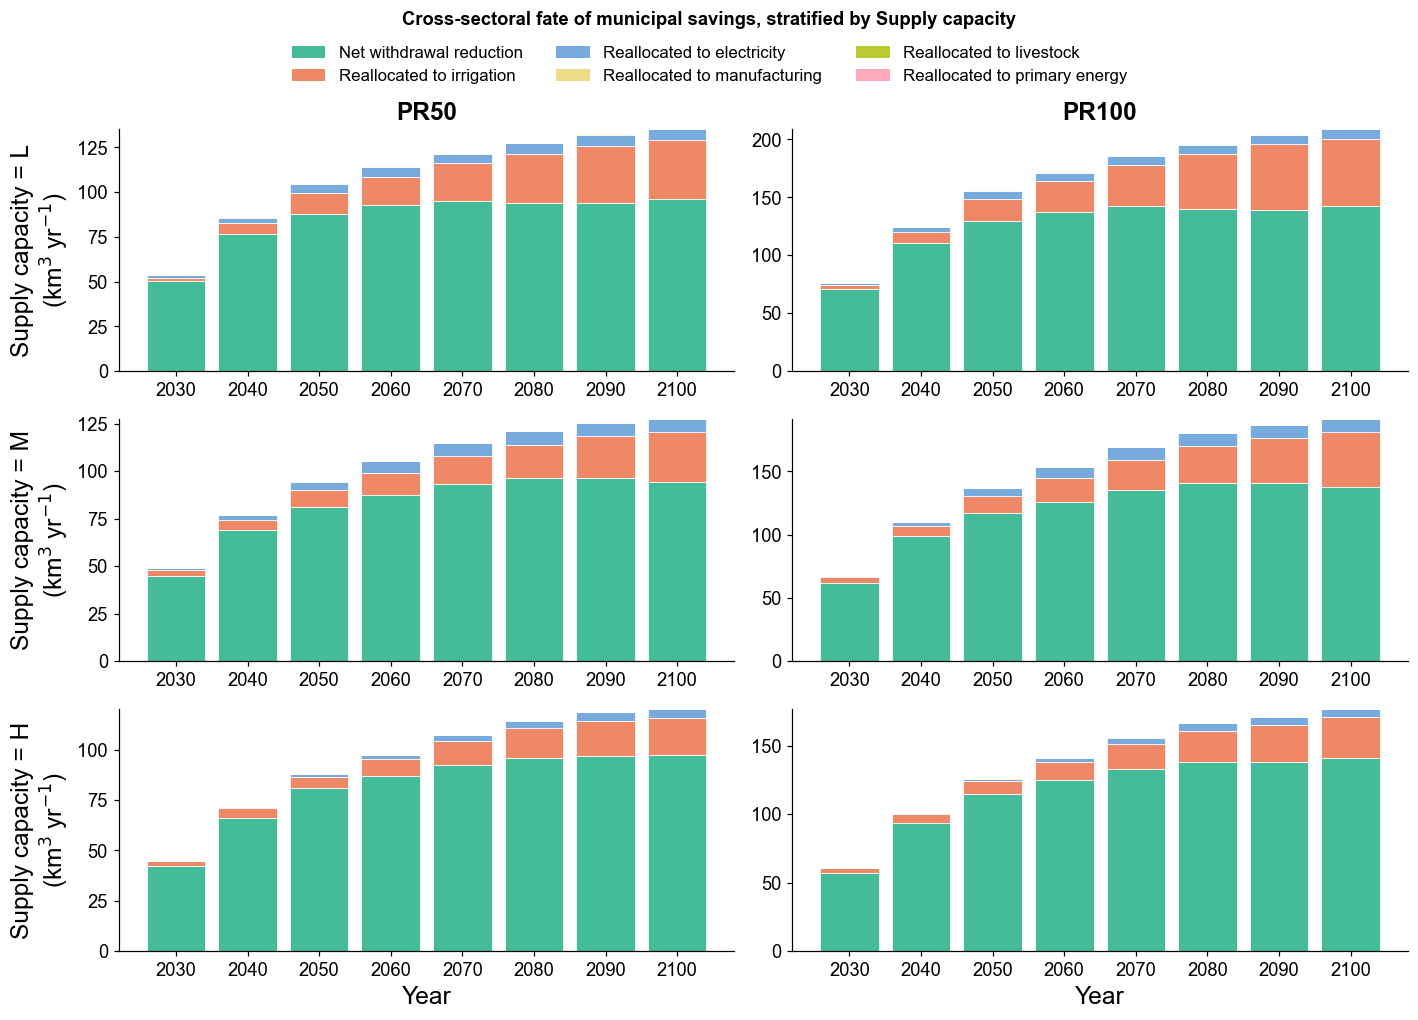

In [10]:
def fate_table_stratified(global_delta, stratum_col):
    """Per-stratum fate decomposition"""
    med = (global_delta
           .groupby(["pr", stratum_col, "sector", "year"],
                    as_index=False)["delta"]
           .median())
    rows = []
    for (pr, stratum, year), sub in med.groupby(["pr", stratum_col, "year"]):
        s = dict(zip(sub["sector"], sub["delta"]))
        muni = -s.get("Municipal", 0.0)
        if muni <= 0:
            continue
        row = {"pr": pr, stratum_col: stratum, "year": year,
               "gross_municipal": muni}
        net = muni
        for sector in ["Irrigation", "Electricity",
                       "Manufacturing", "Livestock",
                       "Primary energy"]:
            realloc = max(0.0, s.get(sector, 0.0))
            row[FATE_COL[f"Reallocated to {sector.lower()}"]] = realloc
            net -= realloc
        row[FATE_COL["Net withdrawal reduction"]] = max(0.0, net)
        rows.append(row)
    return pd.DataFrame(rows)


def figure_si_stratified(global_delta, stratum_col, stratum_order,
                         label, out_stem):
    """Grid figure: rows = strata, cols = PR50/PR100, stacked decadal bars."""
    fate_df = fate_table_stratified(global_delta, stratum_col)
    fate_df = fate_df[fate_df["year"].isin(DECADES)].copy()

    nrows = len(stratum_order)
    fig, axes = plt.subplots(
        nrows, 2, figsize=(13, 2.6 * nrows + 1.2),
        sharex=False, sharey=False,
    )
    if nrows == 1:
        axes = np.atleast_2d(axes)

    x = np.arange(len(DECADES))

    for ri, level in enumerate(stratum_order):
        for ci, pr in enumerate(PR_LEVELS):
            ax = axes[ri, ci]
            sub = (fate_df[(fate_df[stratum_col] == level)
                           & (fate_df["pr"] == pr)]
                   .set_index("year").reindex(DECADES))
            if sub.empty or sub[FATE_COL[FATE_ORDER[0]]].isna().all():
                ax.set_visible(False)
                continue

            bottom = np.zeros(len(DECADES))
            for fate_name in FATE_ORDER:
                col  = FATE_COL[fate_name]
                vals = sub[col].fillna(0).to_numpy()
                ax.bar(x, vals, bottom=bottom, width=0.82,
                       color=FATE_COLOR[fate_name],
                       edgecolor="white", linewidth=0.5)
                bottom += vals

            ax.set_xticks(x)
            ax.set_xticklabels(DECADES, rotation=0)
            if ri == 0:
                ax.set_title(pr, fontweight="bold")
            if ci == 0:
                ax.set_ylabel(f"{label} = {level}\n(km$^3$ yr$^{{-1}}$)")
            if ri == nrows - 1:
                ax.set_xlabel("Year")

    handles = [Patch(facecolor=FATE_COLOR[f], label=f) for f in FATE_ORDER]
    fig.legend(handles=handles, loc="upper center", ncol=3,
               frameon=False, bbox_to_anchor=(0.5, 1.005))
    fig.suptitle(
        f"Cross-sectoral fate of municipal savings, stratified by {label}",
        fontweight="bold", y=1.025,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.985])
    save_all(fig, FIG_DIR, out_stem)
    plt.show()
    plt.close(fig)


figure_si_stratified(global_delta, "ssp",
                     [f"SSP{i}" for i in range(1, 6)],
                     label="SSP",
                     out_stem="figSI_fate_stratified_by_ssp")

figure_si_stratified(global_delta, "rcp",
                     sorted(global_delta["rcp"].unique()),
                     label="RCP",
                     out_stem="figSI_fate_stratified_by_rcp")

figure_si_stratified(global_delta, "rc",
                     ["LRC", "MRC", "HRC"],
                     label="Reuse cost",
                     out_stem="figSI_fate_stratified_by_reuse_cost")

figure_si_stratified(global_delta, "supply",
                     ["L", "M", "H"],
                     label="Supply capacity",
                     out_stem="figSI_fate_stratified_by_supply_capacity")

### Headline numbers

Writes a small text file with the median values cited in the manuscript (gross municipal reduction, sector-by-sector reallocation shares, net retention) for both PR50 and PR100 at end-of-century. Useful as a quick check that the figure outputs and the body text.

In [11]:
def headline_numbers(fate_df, gross_df,
                     years=(2030, 2050, 2075, 2100),
                     pr_levels=None):
    """
    Print ensemble-median headline numbers for each (PR, year) pair, with
    IQR (q25-q75) and 5-95% ranges for the gross municipal reduction.
    """
    if pr_levels is None:
        pr_levels = PR_LEVELS

    lines = []
    for pr in pr_levels:
        lines.append(f"\n{'=' * 72}")
        lines.append(f"  {pr}")
        lines.append(f"{'=' * 72}")

        for year in years:
            row = fate_df[(fate_df["pr"] == pr) & (fate_df["year"] == year)]
            if row.empty:
                lines.append(f"\n  --- {year}: no data ---")
                continue
            row = row.iloc[0]
            muni = row["gross_municipal"]

            g = gross_df[(gross_df["pr"] == pr) & (gross_df["year"] == year)]
            g_iqr = g.iloc[0] if not g.empty else None

            lines.append(f"\n  --- {year} (ensemble medians) ---")
            if g_iqr is not None:
                lines.append(
                    f"    Gross municipal reduction      = {muni:6.1f} km3 yr-1  "
                    f"(IQR {g_iqr['q25']:.1f}-{g_iqr['q75']:.1f}; "
                    f"5-95% {g_iqr['q05']:.1f}-{g_iqr['q95']:.1f})"
                )
            else:
                lines.append(
                    f"    Gross municipal reduction      = {muni:6.1f} km3 yr-1"
                )

            for sector in ["irrigation", "electricity", "manufacturing",
                           "livestock", "primary energy"]:
                v = row[FATE_COL[f"Reallocated to {sector}"]]
                pct = 100 * v / muni if muni else 0
                lines.append(
                    f"    Reallocated to {sector:<14s} = {v:6.1f}  "
                    f"({pct:4.1f}% of gross)"
                )

            net = row[FATE_COL["Net withdrawal reduction"]]
            net_pct = 100 * net / muni if muni else 0
            lines.append(
                f"    Net withdrawal reduction       = {net:6.1f}  "
                f"({net_pct:4.1f}%)"
            )
    return "\n".join(lines)


# Match the years + PR levels shown in Figure 1
YEARS_REPORT = [2030, 2050, 2075, 2100]
PR_REPORT    = ["PR50", "PR100"]   # set to None to use full PR_LEVELS

text = headline_numbers(fate, gross, years=YEARS_REPORT, pr_levels=PR_REPORT)
out  = FIG_DIR / "headline_numbers.txt"
out.write_text(text, encoding="utf-8")
print(text)
print(f"\nWrote {out}")


  PR50

  --- 2030 (ensemble medians) ---
    Gross municipal reduction      =   48.8 km3 yr-1  (IQR 3.5-105.7; 5-95% 2.9-106.6)
    Reallocated to irrigation     =    2.7  ( 5.5% of gross)
    Reallocated to electricity    =    0.1  ( 0.2% of gross)
    Reallocated to manufacturing  =    0.0  ( 0.1% of gross)
    Reallocated to livestock      =    0.0  ( 0.0% of gross)
    Reallocated to primary energy =    0.0  ( 0.0% of gross)
    Net withdrawal reduction       =   46.0  (94.2%)

  --- 2050 (ensemble medians) ---
    Gross municipal reduction      =   94.6 km3 yr-1  (IQR 8.2-150.9; 5-95% 6.1-152.6)
    Reallocated to irrigation     =    8.6  ( 9.1% of gross)
    Reallocated to electricity    =    2.7  ( 2.9% of gross)
    Reallocated to manufacturing  =    0.1  ( 0.1% of gross)
    Reallocated to livestock      =    0.0  ( 0.0% of gross)
    Reallocated to primary energy =    0.0  ( 0.0% of gross)
    Net withdrawal reduction       =   83.2  (87.9%)

  --- 2075 (ensemble medians) -

## Generate the final 4 panelled figure 1

  Saved: Figure1.png | Figure1.svg | Figure1.html


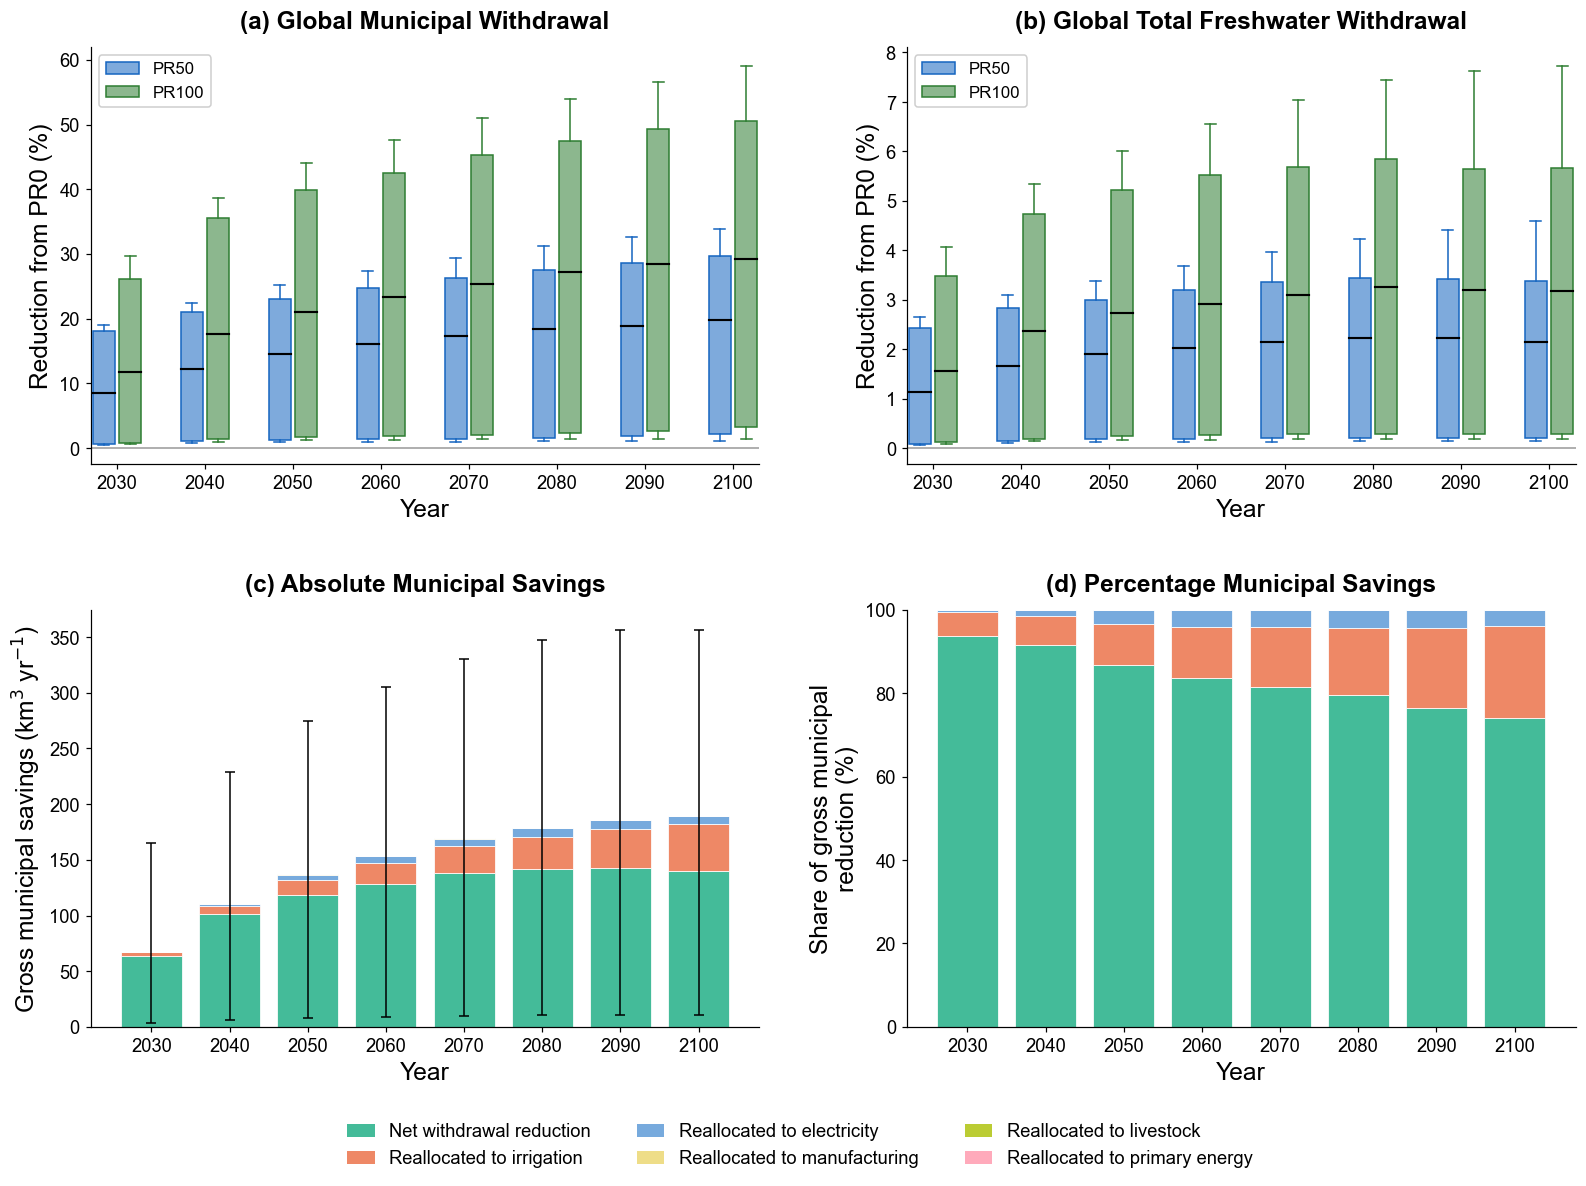

In [12]:
# ============================================================
# Combined Figure 1 (a, b, c, d) on a single 2x2 canvas.
# Reads muni_red, total_red, fate and gross, all computed earlier.
# ============================================================

fig = plt.figure(figsize=(15, 11))
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1, 1], height_ratios=[1, 1],
    left=0.07, right=0.97, top=0.95, bottom=0.14,
    hspace=0.35, wspace=0.22,
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

years     = DECADES
box_width = 2.5
offset    = 3.0


# --- Panels (a) and (b): paired boxplots ---------------------
def _draw_boxplot(ax, df, title):
    for pi, pr in enumerate(PR_LEVELS):
        pos  = [y + (pi - 0.5) * offset for y in years]
        data = [df[(df["pr"] == pr) & (df["year"] == y)]
                  ["pct_reduction"].dropna().values
                for y in years]
        ax.boxplot(
            data, positions=pos, widths=box_width,
            patch_artist=True, showfliers=False,
            medianprops=dict(color="black", linewidth=1.4),
            whiskerprops=dict(color=PR_COLOR[pr], linewidth=1.0),
            capprops=dict(color=PR_COLOR[pr], linewidth=1.0),
            boxprops=dict(
                facecolor=hex_to_rgba_mpl(PR_COLOR[pr], 0.55),
                edgecolor=PR_COLOR[pr], linewidth=1.0),
            zorder=3,
        )
    ax.axhline(0, color="#555", linewidth=1.0, alpha=0.6, zorder=1)
    ax.set_title(title, fontweight="bold", pad=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("Reduction from PR0 (%)")
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years])
    pad = max(3, (years[-1] - years[0]) * 0.04)
    ax.set_xlim(years[0] - pad, years[-1] + pad)
    handles = [
        mpatches.Patch(
            facecolor=hex_to_rgba_mpl(PR_COLOR[pr], 0.55),
            edgecolor=PR_COLOR[pr], label=pr)
        for pr in PR_LEVELS
    ]
    ax.legend(handles=handles, loc="upper left", framealpha=0.95)


_draw_boxplot(ax_a, muni_red,  "(a) Global Municipal Withdrawal")
_draw_boxplot(ax_b, total_red, "(b) Global Total Freshwater Withdrawal")


# --- Panels (c) and (d): PR100 fate decomposition ------------
f_pr = fate[fate["pr"] == "PR100"].set_index("year").reindex(DECADES)
g_pr = gross[gross["pr"] == "PR100"].set_index("year").reindex(DECADES)
x    = np.arange(len(DECADES))

# (c) absolute volumes plus a 5-95% whisker on the gross saving.
bottom = np.zeros(len(DECADES))
for fate_name in FATE_ORDER:
    vals = f_pr[FATE_COL[fate_name]].fillna(0).to_numpy()
    ax_c.bar(x, vals, bottom=bottom, width=0.78,
             color=FATE_COLOR[fate_name],
             edgecolor="white", linewidth=0.5)
    bottom += vals

g_med  = g_pr["median"].to_numpy()
err_lo = np.clip(g_med - g_pr["q05"].to_numpy(), 0, None)
err_hi = np.clip(g_pr["q95"].to_numpy() - g_med, 0, None)
ax_c.errorbar(x, g_med, yerr=[err_lo, err_hi],
              fmt="none", ecolor="#000",
              elinewidth=1.0, capsize=3.0, capthick=1.0, zorder=10)

ax_c.set_xticks(x)
ax_c.set_xticklabels(DECADES)
ax_c.set_xlabel("Year")
ax_c.set_ylabel("Gross municipal savings (km$^3$ yr$^{-1}$)")
ax_c.set_title("(c) Absolute Municipal Savings", fontweight="bold", pad=12)

# (d) proportional shares.
totals = f_pr[[FATE_COL[f] for f in FATE_ORDER]].sum(axis=1)
bottom = np.zeros(len(DECADES))
for fate_name in FATE_ORDER:
    vals = (f_pr[FATE_COL[fate_name]].fillna(0)
            / totals.replace(0, np.nan) * 100).fillna(0).to_numpy()
    ax_d.bar(x, vals, bottom=bottom, width=0.78,
             color=FATE_COLOR[fate_name],
             edgecolor="white", linewidth=0.5)
    bottom += vals

ax_d.set_xticks(x)
ax_d.set_xticklabels(DECADES)
ax_d.set_xlabel("Year")
ax_d.set_ylabel("Share of gross municipal\nreduction (%)")
ax_d.set_ylim(0, 100)
ax_d.set_title("(d) Percentage Municipal Savings", fontweight="bold", pad=12)


# --- Shared fate legend across the bottom --------------------
fate_handles = [Patch(facecolor=FATE_COLOR[f], label=f) for f in FATE_ORDER]
fig.legend(
    handles=fate_handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01),
    fontsize=12,
    columnspacing=2.5,
    handlelength=1.5,
)

save_all(fig, FIG_DIR, "Figure1")
plt.show()
plt.close(fig)

### Misc headline numbers for text - rechecking

In [13]:

# -------------------------------------------------------------
# 1. Snapshot text (medians + IQR + 5-95%) for milestone years
# -------------------------------------------------------------
def headline_numbers(fate_df, gross_df,
                     years=(2030, 2050, 2075, 2100),
                     pr_levels=None):
    if pr_levels is None:
        pr_levels = PR_LEVELS

    lines = []
    for pr in pr_levels:
        lines.append(f"\n{'=' * 72}\n  {pr}\n{'=' * 72}")
        for year in years:
            row = fate_df[(fate_df["pr"] == pr) & (fate_df["year"] == year)]
            if row.empty:
                lines.append(f"\n  --- {year}: no data ---")
                continue
            row  = row.iloc[0]
            muni = row["gross_municipal"]

            g     = gross_df[(gross_df["pr"] == pr) & (gross_df["year"] == year)]
            g_iqr = g.iloc[0] if not g.empty else None

            lines.append(f"\n  --- {year} (ensemble medians) ---")
            if g_iqr is not None:
                lines.append(
                    f"    Gross municipal reduction      = {muni:6.1f} km3 yr-1  "
                    f"(IQR {g_iqr['q25']:.1f}-{g_iqr['q75']:.1f}; "
                    f"5-95% {g_iqr['q05']:.1f}-{g_iqr['q95']:.1f})"
                )
            else:
                lines.append(
                    f"    Gross municipal reduction      = {muni:6.1f} km3 yr-1"
                )
            for sector in ["irrigation", "electricity", "manufacturing",
                           "livestock", "primary energy"]:
                v   = row[FATE_COL[f"Reallocated to {sector}"]]
                pct = 100 * v / muni if muni else 0
                lines.append(
                    f"    Reallocated to {sector:<14s} = {v:6.1f}  ({pct:4.1f}% of gross)"
                )
            net     = row[FATE_COL["Net withdrawal reduction"]]
            net_pct = 100 * net / muni if muni else 0
            lines.append(
                f"    Net withdrawal reduction       = {net:6.1f}  ({net_pct:4.1f}%)"
            )
    return "\n".join(lines)


# -------------------------------------------------------------
# 2. Tidy long-format table: every PR x year, absolute + % of gross
#    (this is what reproduces the stacked-bar shares)
# -------------------------------------------------------------
def fate_breakdown_table(fate_df, gross_df, pr_levels=None):
    if pr_levels is None:
        pr_levels = PR_LEVELS

    sectors = ["irrigation", "electricity", "manufacturing",
               "livestock", "primary energy"]

    rows = []
    for _, r in fate_df[fate_df["pr"].isin(pr_levels)].iterrows():
        muni = r["gross_municipal"]
        g    = gross_df[(gross_df["pr"] == r["pr"]) & (gross_df["year"] == r["year"])]
        g    = g.iloc[0] if not g.empty else None

        base = {
            "pr":              r["pr"],
            "year":            int(r["year"]),
            "gross_municipal": muni,
            "gross_q05": g["q05"] if g is not None else None,
            "gross_q25": g["q25"] if g is not None else None,
            "gross_q75": g["q75"] if g is not None else None,
            "gross_q95": g["q95"] if g is not None else None,
        }
        for s in sectors:
            v = r[FATE_COL[f"Reallocated to {s}"]]
            base[f"{s}_abs"] = v
            base[f"{s}_pct"] = 100 * v / muni if muni else 0
        net = r[FATE_COL["Net withdrawal reduction"]]
        base["net_abs"] = net
        base["net_pct"] = 100 * net / muni if muni else 0
        rows.append(base)

    return pd.DataFrame(rows).sort_values(["pr", "year"]).reset_index(drop=True)


# -------------------------------------------------------------
# 3. Wide decadal % matrix (one column per sector, rows = year)
#    -> mirrors what the decadal line plot shows
# -------------------------------------------------------------
def decadal_percent_matrix(breakdown_df, pr, decade_step=10, year0=2020):
    sub = breakdown_df[(breakdown_df["pr"] == pr) &
                       (breakdown_df["year"] % decade_step == year0 % decade_step)]
    cols = [c for c in sub.columns if c.endswith("_pct")]
    return sub[["year"] + cols].set_index("year").round(1)


# -------------------------------------------------------------
# 4. Run + write outputs
# -------------------------------------------------------------
PR_REPORT    = ["PR50", "PR100"]            # adjust if zero-padded in your data
YEARS_REPORT = [2030, 2050, 2075, 2100]

# (a) milestone-year text
text = headline_numbers(fate, gross, years=YEARS_REPORT, pr_levels=PR_REPORT)
(FIG_DIR / "headline_numbers.txt").write_text(text, encoding="utf-8")
print(text)

# (b) full breakdown table
breakdown = fate_breakdown_table(fate, gross, pr_levels=PR_REPORT)
breakdown.to_csv(FIG_DIR / "fate_breakdown_long.csv", index=False)
print("\nWrote fate_breakdown_long.csv")

# (c) decadal percentage matrix per PR
for pr in PR_REPORT:
    mat = decadal_percent_matrix(breakdown, pr)
    mat.to_csv(FIG_DIR / f"decadal_pct_{pr}.csv")
    print(f"\n--- Decadal % of gross municipal, {pr} ---")
    print(mat)


  PR50

  --- 2030 (ensemble medians) ---
    Gross municipal reduction      =   48.8 km3 yr-1  (IQR 3.5-105.7; 5-95% 2.9-106.6)
    Reallocated to irrigation     =    2.7  ( 5.5% of gross)
    Reallocated to electricity    =    0.1  ( 0.2% of gross)
    Reallocated to manufacturing  =    0.0  ( 0.1% of gross)
    Reallocated to livestock      =    0.0  ( 0.0% of gross)
    Reallocated to primary energy =    0.0  ( 0.0% of gross)
    Net withdrawal reduction       =   46.0  (94.2%)

  --- 2050 (ensemble medians) ---
    Gross municipal reduction      =   94.6 km3 yr-1  (IQR 8.2-150.9; 5-95% 6.1-152.6)
    Reallocated to irrigation     =    8.6  ( 9.1% of gross)
    Reallocated to electricity    =    2.7  ( 2.9% of gross)
    Reallocated to manufacturing  =    0.1  ( 0.1% of gross)
    Reallocated to livestock      =    0.0  ( 0.0% of gross)
    Reallocated to primary energy =    0.0  ( 0.0% of gross)
    Net withdrawal reduction       =   83.2  (87.9%)

  --- 2075 (ensemble medians) -

### Additional SI panel for showing spread of MRC, HRC, LRC

  Saved: figSI_bimodality_scatter_2100.png | figSI_bimodality_scatter_2100.svg | figSI_bimodality_scatter_2100.html


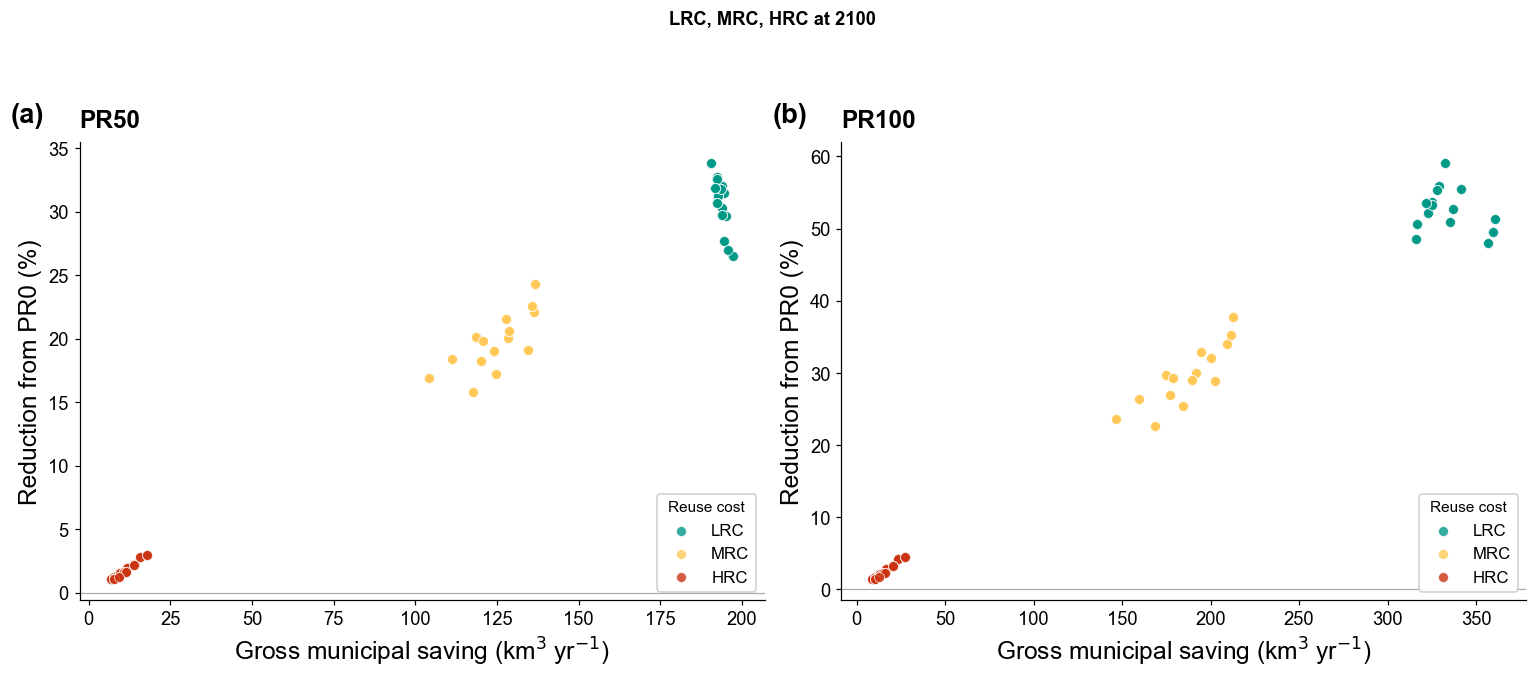

In [15]:
# ============================================================
# SI panel: bimodality scatter at 2100, PR50 and PR100
# Each point is one ensemble member at 2100. y-axis is the
# pct_reduction metric used in the manuscript text. x-axis
# is gross municipal saving, which spreads the points so the
# regime clusters are individually resolvable rather than
# stacked on a single vertical.
# ============================================================

RC_COLOR = {
    "LRC": "#009988",   # teal-green
    "MRC": "#FFC857",   # mustard
    "HRC": "#CC3311",   # red
}
RC_ORDER = ["LRC", "MRC", "HRC"]


def scatter_bimodality_2100(muni_red, out_stem,
                            year=2100,
                            marker_size=42, alpha=0.80):
    """Two-panel scatter: pct_reduction at 2100, PR50 (a) and PR100 (b).

    Each point is one ensemble member, colored by reuse cost class.
    The y-axis carries the pct_reduction metric from the manuscript
    text; the x-axis (gross saving) is included only to spread the
    points horizontally so individual scenarios are visible.
    """
    df = muni_red[muni_red["year"] == year].copy()
    if df.empty:
        print(f"[warn] no rows at year={year}")
        return
    df["gross_saving"] = df["ref"] - df["withdrawal"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6.0),
                             sharex=False, sharey=False)

    for ax, pr in zip(axes, PR_LEVELS):
        sub = df[df["pr"] == pr]
        for rc in RC_ORDER:
            s = sub[sub["rc"] == rc]
            if s.empty:
                continue
            ax.scatter(s["gross_saving"], s["pct_reduction"],
                       s=marker_size,
                       facecolor=RC_COLOR[rc],
                       edgecolor="white", linewidth=0.5,
                       alpha=alpha, label=rc, zorder=3)

        ax.axhline(0, color="#555", linewidth=0.8, alpha=0.5, zorder=1)
        ax.set_xlabel(r"Gross municipal saving (km$^3$ yr$^{-1}$)")
        ax.set_ylabel("Reduction from PR0 (%)")
        ax.set_title(pr, fontweight="bold", pad=10, loc="left")
        ax.legend(title="Reuse cost", loc="lower right",
                  framealpha=0.95)

    for letter, ax in zip("ab", axes):
        ax.text(-0.10, 1.03, f"({letter})",
                transform=ax.transAxes,
                fontsize=18, fontweight="bold",
                va="bottom", ha="left")

    fig.suptitle(f"LRC, MRC, HRC at {year}",
                 fontweight="bold", y=1.02)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    save_all(fig, FIG_DIR, out_stem)
    plt.show()
    plt.close(fig)


scatter_bimodality_2100(
    muni_red,
    out_stem="figSI_bimodality_scatter_2100",
)